# Stage 0 — COSMOS Manual Cutout Preparation (Clean Version)

**Purpose:** Build a clean source-galaxy library from **manually downloaded** COSMOS HST/ACS F814W FITS cutouts for later lenstronomy simulations.

This notebook intentionally removes all automatic IRSA query/download logic to avoid confusion.

## What this notebook does
1. Reads manually downloaded FITS cutouts from a folder.
2. Extracts sky coordinates from the filename when possible, with WCS fallback.
3. Performs basic image-level QA suited to manual-download workflows.
4. Normalises accepted cutouts and saves them as `.npy` arrays.
5. Writes clean metadata to JSON and CSV.
6. Produces a summary grid JPG for visual inspection.

## Important note
Because you are downloading files manually, **catalog-based star rejection is not being applied here automatically**. You must ensure the FITS files you place in the input folder are already your intended galaxy sample, and this notebook adds only image-level QA plus manual-review support.

## Cell 1 — Install dependencies (run once)

This version uses only packages needed for a **manual FITS workflow**.

In [1]:
import subprocess
import sys

packages = [
    'numpy',
    'pandas',
    'matplotlib',
    'astropy',
    'tqdm',
    'scipy',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Manual-workflow dependencies installed successfully.')

Manual-workflow dependencies installed successfully.


## Cell 2 — Imports and configuration

Set the input folder to wherever you saved your manually downloaded FITS files.

The default pixel scale here is **0.03 arcsec/pixel**, matching COSMOS ACS 30 mas mosaic products. A 10.0 arcsec cutout therefore corresponds to roughly **333–335 pixels** per side, which is consistent with your current files.

In [2]:
import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from scipy import ndimage as ndi

warnings.filterwarnings('ignore')

# =========================
# User configuration
# =========================
RAW_DIR = Path('cosmos_cutouts/fits')
OUT_DIR = Path('cosmos_cutouts')
NPY_DIR = OUT_DIR / 'npy'
MASKED_NPY_DIR = OUT_DIR / "masked_npy"
MASK_DIR = OUT_DIR / "masks"
META_DIR = OUT_DIR / "metadata"
PLOT_DIR = OUT_DIR / "qaplots"

for d in [RAW_DIR, OUT_DIR, NPY_DIR, MASKED_NPY_DIR, MASK_DIR, META_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CUTOUT_SIZE_ARCSEC = 5.0
DEFAULT_PIXEL_SCALE_ARCSEC = 0.03
EXPECTED_SIZE_PIX = int(round(CUTOUT_SIZE_ARCSEC / DEFAULT_PIXEL_SCALE_ARCSEC))

# Manual-review controls
MAX_FILES = None          # set to an integer for testing, e.g. 50
REJECT_BY_FILENAME = set()  # e.g. {'0045_150.143014_2.219132_acs_I_mosaic_30mas_sci.fits'}

# Simple image-level QA thresholds
MIN_STD = 0.003
MAX_PEAK_AFTER_NORM = 20.0
MAX_EDGE_ABS_MEAN = 0.50
MIN_FINITE_FRACTION = 0.98

# ----------------------------
# Advanced rule 1:
# recenter + off-center rejection
# ----------------------------
USE_RULE1_RECENTER = True
RECENTER_MODE = "flux_centroid"   # "flux_centroid" or "catalog_center"
SEG_NSIGMA = 3.0
MIN_COMPONENT_PIXELS = 20
MAX_DOMINANT_OFFSET_PIX = 24.0
MAX_POST_CENTER_OFFSET_PIX = 8.0

# ----------------------------
# Advanced rule 2:
# contaminant rejection
# ----------------------------
USE_RULE2_CONTAMINANT = True
BRIGHT_COMPONENT_FRAC = 0.50
MAX_BRIGHT_COMPONENTS = 2
MIN_MAIN_FLUX_FRACTION = 0.30
MIN_MAIN_AREA_FRACTION = 0.002
STAR_MAX_COMPONENT_PIX = 50
STAR_MIN_FLUX_FRACTION = 0.75
STAR_MIN_PEAKNORM = 4.8
SPIKE_HALF_WIDTH = 2
MAX_SPIKE_CROSS_RATIO = 0.45

# ----------------------------
# Advanced rule 3:
# optional dominant-source mask
# ----------------------------
USE_RULE3_DOMINANT_MASK = True
MASK_DILATION_ITERS = 3
SAVE_MASKS = True
SAVE_MASKED_NPY = True
EXPORT_MASKED_FOR_LENSTRONOMY = False

print(f"Input FITS folder: {RAW_DIR.resolve()}")
print(f"Output folder: {OUT_DIR.resolve()}")
print(f"Cutout size: {CUTOUT_SIZE_ARCSEC:.1f} arcsec")
print(f"Default pixel scale: {DEFAULT_PIXEL_SCALE_ARCSEC:.3f} arcsec/pixel")
print(f"Expected size: {EXPECTED_SIZE_PIX} px per side")
print(f"Rule 1 enabled: {USE_RULE1_RECENTER} ({RECENTER_MODE})")
print(f"Rule 2 enabled: {USE_RULE2_CONTAMINANT}")
print(f"Rule 3 enabled: {USE_RULE3_DOMINANT_MASK}")

Input FITS folder: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\fits
Output folder: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts
Cutout size: 5.0 arcsec
Default pixel scale: 0.030 arcsec/pixel
Expected size: 167 px per side
Rule 1 enabled: True (flux_centroid)
Rule 2 enabled: True
Rule 3 enabled: True


## Cell 3 — Discover manual FITS files

This cell only inspects the input folder and builds the list of candidate files.

In [3]:
fits_files = sorted(RAW_DIR.glob('*.fits')) + sorted(RAW_DIR.glob('*.fit'))

if MAX_FILES is not None:
    fits_files = fits_files[:MAX_FILES]

print(f'Found {len(fits_files)} FITS files.')
for fp in fits_files[:10]:
    print(' -', fp.name)

if len(fits_files) == 0:
    print('No FITS files found. Put your manually downloaded COSMOS cutouts into RAW_DIR and rerun.')

Found 50 FITS files.
 - 0001_150.329073_2.139497_acs_I_mosaic_30mas_sci.fits
 - 0002_150.054801_2.426702_acs_I_mosaic_30mas_sci.fits
 - 0003_150.218429_2.36785_acs_I_mosaic_30mas_sci.fits
 - 0004_150.293615_2.402216_acs_I_mosaic_30mas_sci.fits
 - 0005_150.300439_2.165881_acs_I_mosaic_30mas_sci.fits
 - 0006_149.7983_2.215854_acs_I_mosaic_30mas_sci.fits
 - 0007_149.825905_2.27702_acs_I_mosaic_30mas_sci.fits
 - 0008_150.110179_2.272575_acs_I_mosaic_30mas_sci.fits
 - 0009_150.028484_2.13021_acs_I_mosaic_30mas_sci.fits
 - 0010_150.186217_2.556423_acs_I_mosaic_30mas_sci.fits


## Cell 4 — Helper functions

These helpers do the following:
- recover RA/Dec from the filename when available,
- fall back to FITS WCS if the filename does not contain coordinates,
- estimate pixel scale from the WCS when possible,
- normalise cutouts for downstream use,
- run simple image-level QA suitable for a manual workflow.

In [4]:
COORD_PATTERN = re.compile(
    r"^(?P<idx>\d{4})(?P<ra>\d{3}\.\d+)(?P<dec>-?\d\.\d+)acs",
    re.IGNORECASE
)

def parse_coords_from_filename(filename):
    m = COORD_PATTERN.search(filename)
    if m is None:
        return None, None
    return float(m.group("ra")), float(m.group("dec"))

def get_center_coords_from_wcs(header, shape):
    try:
        w = WCS(header)
        if not w.has_celestial:
            return None, None
        ny, nx = shape
        x_center = (nx - 1) / 2.0
        y_center = (ny - 1) / 2.0
        ra, dec = w.all_pix2world(x_center, y_center, 0)
        return float(ra), float(dec)
    except Exception:
        return None, None

def get_pixel_scale_arcsec(header):
    try:
        w = WCS(header)
        if not w.has_celestial:
            return DEFAULT_PIXEL_SCALE_ARCSEC
        scales = proj_plane_pixel_scales(w.celestial) * 3600.0
        scales = np.asarray(scales, dtype=float)
        if np.all(np.isfinite(scales)) and np.all(scales > 0):
            return float(np.mean(scales))
    except Exception:
        pass
    return DEFAULT_PIXEL_SCALE_ARCSEC

def robust_normalize(img):
    img = np.array(img, dtype=np.float32)
    finite = np.isfinite(img)
    finite_fraction = float(finite.mean())
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    sky_level = float(np.median(img))
    img_sub = img - sky_level

    p99_flux = float(np.percentile(img_sub, 99.0))
    scale = p99_flux if p99_flux > 0 else 1.0

    norm = (img_sub / scale).astype(np.float32)
    norm = np.clip(norm, -1.0, 5.0)

    return norm, sky_level, p99_flux, finite_fraction

def edge_abs_mean(arr):
    edge = np.concatenate([arr[0, :], arr[-1, :], arr[:, 0], arr[:, -1]])
    return float(np.mean(np.abs(edge)))

def qa_checks(norm, finite_fraction, filename):
    reasons = []

    if filename in REJECT_BY_FILENAME:
        reasons.append("manual_filename_reject")

    std = float(np.std(norm))
    peak = float(np.max(norm))
    edge_mean = edge_abs_mean(norm)

    if finite_fraction < MIN_FINITE_FRACTION:
        reasons.append("too_many_nonfinite_pixels")
    if std < MIN_STD:
        reasons.append("near_empty_or_too_flat")
    if peak > MAX_PEAK_AFTER_NORM:
        reasons.append("extreme_peak_possible_star_or_artifact")
    if edge_mean > MAX_EDGE_ABS_MEAN:
        reasons.append("strong_edge_signal_possible_bad_crop")

    return reasons, {
        "stdnorm": std,
        "peaknorm": peak,
        "edgeabsmean": edge_mean,
        "finitefraction": finite_fraction,
    }

def mad_std(arr):
    arr = np.asarray(arr, dtype=float)
    med = np.nanmedian(arr)
    return 1.4826 * np.nanmedian(np.abs(arr - med))

def geom_center(shape):
    ny, nx = shape
    return (0.5 * (ny - 1), 0.5 * (nx - 1))

def detect_components(norm, nsigma=SEG_NSIGMA, min_pixels=MIN_COMPONENT_PIXELS):
    arr = np.asarray(norm, dtype=np.float32)
    bkg = float(np.nanmedian(arr))
    sigma = float(mad_std(arr))
    sigma = max(sigma, 1e-6)

    pos = np.clip(arr - bkg, 0, None)
    binary = pos > (nsigma * sigma)
    binary = ndi.binary_opening(binary, structure=np.ones((3, 3)))
    binary = ndi.binary_closing(binary, structure=np.ones((3, 3)))
    binary = ndi.binary_fill_holes(binary)

    labels, nlab = ndi.label(binary)
    cy0, cx0 = geom_center(arr.shape)
    components = []

    for lab_id in range(1, nlab + 1):
        mask = labels == lab_id
        n_pix = int(mask.sum())
        if n_pix < min_pixels:
            continue

        ys, xs = np.where(mask)
        weights = pos[mask]
        flux = float(weights.sum())
        peak = float(arr[mask].max())

        if flux > 0:
            cy = float(np.sum(ys * weights) / flux)
            cx = float(np.sum(xs * weights) / flux)
        else:
            cy = float(np.mean(ys))
            cx = float(np.mean(xs))

        dist_to_center = float(np.hypot(cy - cy0, cx - cx0))

        components.append({
            "label": int(lab_id),
            "n_pix": n_pix,
            "flux": flux,
            "peak": peak,
            "cy": cy,
            "cx": cx,
            "dist_to_center": dist_to_center,
        })

    components = sorted(components, key=lambda d: d["flux"], reverse=True)
    return labels, components, {"seg_bkg": bkg, "seg_sigma": sigma}

def recenter_on_component(norm, component):
    arr = np.asarray(norm, dtype=np.float32)
    cy0, cx0 = geom_center(arr.shape)
    shift_y = cy0 - component["cy"]
    shift_x = cx0 - component["cx"]
    fill = float(np.nanmedian(arr))
    shifted = ndi.shift(arr, shift=(shift_y, shift_x), order=1, mode="constant", cval=fill)
    return shifted.astype(np.float32), float(shift_y), float(shift_x)

def apply_rule1_recenter(norm):
    arr = np.asarray(norm, dtype=np.float32).copy()
    labels, components, segstats = detect_components(arr)

    info = {
        "r1_pre_offset_pix": np.nan,
        "r1_post_offset_pix": np.nan,
        "r1_shift_y": 0.0,
        "r1_shift_x": 0.0,
        "r1_n_components": len(components),
        **segstats,
    }
    reasons = []

    if len(components) == 0:
        reasons.append("r1_no_component_detected")
        return arr, None, None, reasons, info

    dom = components[0]
    info["r1_pre_offset_pix"] = float(dom["dist_to_center"])

    if RECENTER_MODE == "flux_centroid":
        arr, shift_y, shift_x = recenter_on_component(arr, dom)
        info["r1_shift_y"] = shift_y
        info["r1_shift_x"] = shift_x

        labels, components, segstats2 = detect_components(arr)
        info.update(segstats2)
        info["r1_n_components"] = len(components)

        if len(components) == 0:
            reasons.append("r1_no_component_after_recenter")
            return arr, None, None, reasons, info

        dom = components[0]

    dom_mask = labels == dom["label"]
    info["r1_post_offset_pix"] = float(dom["dist_to_center"])

    if info["r1_pre_offset_pix"] > MAX_DOMINANT_OFFSET_PIX:
        reasons.append("r1_dominant_component_far_from_catalog_center")
    if info["r1_post_offset_pix"] > MAX_POST_CENTER_OFFSET_PIX:
        reasons.append("r1_dominant_component_not_centered")

    return arr, dom, dom_mask, reasons, info

def central_cross_fraction(norm, half_width=SPIKE_HALF_WIDTH):
    arr = np.asarray(norm, dtype=np.float32)
    pos = np.clip(arr - np.nanmedian(arr), 0, None)
    total_flux = float(pos.sum()) + 1e-8

    cy0, cx0 = geom_center(arr.shape)
    iy = int(round(cy0))
    ix = int(round(cx0))

    y0 = max(0, iy - half_width)
    y1 = min(arr.shape[0], iy + half_width + 1)
    x0 = max(0, ix - half_width)
    x1 = min(arr.shape[1], ix + half_width + 1)

    row_flux = float(pos[y0:y1, :].sum())
    col_flux = float(pos[:, x0:x1].sum())
    overlap_flux = float(pos[y0:y1, x0:x1].sum())

    cross_flux = row_flux + col_flux - overlap_flux
    return cross_flux / total_flux

def apply_rule2_contaminants(norm):
    arr = np.asarray(norm, dtype=np.float32)
    labels, components, segstats = detect_components(arr)

    info = {
        "r2_n_components": len(components),
        "r2_n_bright_components": 0,
        "r2_main_flux_fraction": np.nan,
        "r2_main_area_fraction": np.nan,
        "r2_spike_cross_ratio": np.nan,
        "r2_main_peaknorm": np.nan,
        **segstats,
    }
    reasons = []

    if len(components) == 0:
        reasons.append("r2_no_component_detected")
        return None, reasons, info

    dom = components[0]
    dom_mask = labels == dom["label"]

    pos = np.clip(arr - np.nanmedian(arr), 0, None)
    total_pos_flux = float(pos.sum()) + 1e-8

    bright_flux_cut = BRIGHT_COMPONENT_FRAC * dom["flux"]
    n_bright = int(sum(c["flux"] >= bright_flux_cut for c in components))
    main_flux_fraction = float(dom["flux"] / total_pos_flux)
    main_area_fraction = float(dom["n_pix"] / arr.size)
    spike_cross_ratio = float(central_cross_fraction(arr, half_width=SPIKE_HALF_WIDTH))
    main_peaknorm = float(dom["peak"])

    info["r2_n_bright_components"] = n_bright
    info["r2_main_flux_fraction"] = main_flux_fraction
    info["r2_main_area_fraction"] = main_area_fraction
    info["r2_spike_cross_ratio"] = spike_cross_ratio
    info["r2_main_peaknorm"] = main_peaknorm

    pointlike = (
        dom["n_pix"] <= STAR_MAX_COMPONENT_PIX
        and main_flux_fraction >= STAR_MIN_FLUX_FRACTION
        and main_peaknorm >= STAR_MIN_PEAKNORM
    )
    spike_like = pointlike and (spike_cross_ratio >= MAX_SPIKE_CROSS_RATIO)

    if n_bright > MAX_BRIGHT_COMPONENTS:
        reasons.append("r2_multiple_bright_objects")
    if main_flux_fraction < MIN_MAIN_FLUX_FRACTION:
        reasons.append("r2_main_object_too_weak")
    if main_area_fraction < MIN_MAIN_AREA_FRACTION:
        reasons.append("r2_main_object_too_small")
    if spike_like:
        reasons.append("r2_bright_star_or_spike_artifact")

    return dom_mask, reasons, info

def apply_rule3_dominant_mask(norm, dominant_mask=None):
    arr = np.asarray(norm, dtype=np.float32).copy()

    if dominant_mask is None or int(np.sum(dominant_mask)) == 0:
        labels, components, _ = detect_components(arr)
        if len(components) == 0:
            return None, arr, {
                "r3_mask_pixels": 0,
                "r3_mask_fraction": 0.0,
            }
        dominant_mask = labels == components[0]["label"]

    mask = ndi.binary_dilation(dominant_mask, iterations=MASK_DILATION_ITERS)
    mask = ndi.binary_fill_holes(mask)

    masked = arr.copy()
    fill_value = float(np.nanmedian(arr))
    masked[~mask] = fill_value

    info = {
        "r3_mask_pixels": int(mask.sum()),
        "r3_mask_fraction": float(mask.mean()),
    }

    return mask.astype(np.uint8), masked.astype(np.float32), info

## Cell 5 — Read FITS files and build a manifest

This cell creates a table describing every available manual cutout **before** any acceptance/rejection decision is made.

In [5]:
manifest = []
image_store = {}
masked_npy_store = {}
mask_store = {}

for fp in tqdm(fits_files, desc="Reading FITS files"):
    try:
        with fits.open(fp, memmap=False) as hdul:
            data = hdul[0].data
            header = hdul[0].header

        if data is None:
            manifest.append({
                "filename": fp.name,
                "status": "reject",
                "reason": "empty_primary_hdu",
            })
            continue

        data = np.squeeze(np.array(data))
        if data.ndim != 2:
            manifest.append({
                "filename": fp.name,
                "status": "reject",
                "reason": f"non_2d_shape_{data.shape}",
            })
            continue

        ra, dec = parse_coords_from_filename(fp.name)
        if ra is None or dec is None:
            ra, dec = get_center_coords_from_wcs(header, data.shape)

        pixel_scale = get_pixel_scale_arcsec(header)
        norm, sky_level, p99_flux, finite_fraction = robust_normalize(data)

        all_reasons = []
        basic_reasons, basic_stats = qa_checks(norm, finite_fraction, fp.name)
        all_reasons.extend(basic_reasons)

        work_img = norm.copy()
        dominant_mask = None
        masked_img = None

        r1_stats = {}
        r2_stats = {}
        r3_stats = {}

        if USE_RULE1_RECENTER:
            work_img, dom, dominant_mask, r1_reasons, r1_stats = apply_rule1_recenter(work_img)
            all_reasons.extend(r1_reasons)

        if USE_RULE2_CONTAMINANT:
            dominant_mask, r2_reasons, r2_stats = apply_rule2_contaminants(work_img)
            all_reasons.extend(r2_reasons)

        if USE_RULE3_DOMINANT_MASK:
            dominant_mask, masked_img, r3_stats = apply_rule3_dominant_mask(work_img, dominant_mask)

        status = "accept" if len(all_reasons) == 0 else "reject"
        reason = "passed_auto_qa" if status == "accept" else ";".join(all_reasons)

        record = {
            "filename": fp.name,
            "path": str(fp),
            "ra": None if ra is None else float(ra),
            "dec": None if dec is None else float(dec),
            "shapey": int(data.shape[0]),
            "shapex": int(data.shape[1]),
            "pixelscalearcsec": float(pixel_scale),
            "cutoutsizearcsecy": float(data.shape[0] * pixel_scale),
            "cutoutsizearcsecx": float(data.shape[1] * pixel_scale),
            "skylevel": float(sky_level),
            "p99flux": float(p99_flux),
            "status": status,
            "reason": reason,
            **basic_stats,
            **r1_stats,
            **r2_stats,
            **r3_stats,
        }

        manifest.append(record)
        image_store[fp.name] = work_img.astype(np.float32)

        if masked_img is not None:
            masked_npy_store[fp.name] = masked_img.astype(np.float32)
        if dominant_mask is not None:
            mask_store[fp.name] = dominant_mask.astype(np.uint8)

    except Exception as e:
        manifest.append({
            "filename": fp.name,
            "status": "reject",
            "reason": f"exception_{type(e).__name__}_{e}",
        })

manifest_df = pd.DataFrame(manifest)
manifest_df.head()

Reading FITS files:   0%|          | 0/50 [00:00<?, ?it/s]

,filename,path,ra,dec,shapey,shapex,pixelscalearcsec,cutoutsizearcsecy,cutoutsizearcsecx,skylevel,...,seg_bkg,seg_sigma,r2_n_components,r2_n_bright_components,r2_main_flux_fraction,r2_main_area_fraction,r2_spike_cross_ratio,r2_main_peaknorm,r3_mask_pixels,r3_mask_fraction
0,0001_150.329073_2.139497_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0001_150.329073_2.139497_a...,150.329074,2.139499,168,168,0.03,5.04,5.04,0.013445,...,-1.371973e-09,0.048364,1,1,0.853211,0.223604,0.199168,2.219919,7522,0.266511
1,0002_150.054801_2.426702_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0002_150.054801_2.426702_a...,150.054806,2.426694,168,168,0.03,5.04,5.04,0.001958,...,-8.141114e-10,0.026802,1,1,0.859799,0.124823,0.338578,5.000000,4211,0.149199
2,0003_150.218429_2.36785_acs_I_mosaic_30mas_sci...,cosmos_cutouts\fits\0003_150.218429_2.36785_ac...,150.218430,2.367851,168,168,0.03,5.04,5.04,0.003816,...,3.470859e-10,0.016857,1,1,0.921464,0.169997,0.290722,3.941596,5573,0.197456
3,0004_150.293615_2.402216_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0004_150.293615_2.402216_a...,150.293615,2.402218,168,168,0.03,5.04,5.04,0.000758,...,0.000000e+00,0.061213,1,1,0.662850,0.062890,0.285873,4.909474,2303,0.081597
4,0005_150.300439_2.165881_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0005_150.300439_2.165881_a...,150.300441,2.165877,168,168,0.03,5.04,5.04,0.001014,...,-1.732417e-09,0.066679,2,1,0.659467,0.070224,0.297065,5.000000,2720,0.096372


## Cell 6 — Inspect acceptance/rejection summary

Because this is a manual-download notebook, this summary is your main sanity check before export.

In [6]:
print('Total files   :', len(manifest_df))
print('Accepted      :', int((manifest_df['status'] == 'accept').sum()))
print('Rejected      :', int((manifest_df['status'] == 'reject').sum()))

print('Rejection reasons:')
print(manifest_df['reason'].value_counts(dropna=False).head(20))

accepted_df = manifest_df[manifest_df['status'] == 'accept'].copy().reset_index(drop=True)
rejected_df = manifest_df[manifest_df['status'] == 'reject'].copy().reset_index(drop=True)

accepted_df.head()

Total files   : 50
Accepted      : 18
Rejected      : 32
Rejection reasons:
reason
passed_auto_qa                                                                      18
r2_main_object_too_weak                                                             15
r1_no_component_detected;r2_no_component_detected                                    6
r1_dominant_component_far_from_catalog_center                                        5
r1_dominant_component_far_from_catalog_center;r2_main_object_too_weak                4
r1_dominant_component_far_from_catalog_center;r1_dominant_component_not_centered     2
Name: count, dtype: int64


,filename,path,ra,dec,shapey,shapex,pixelscalearcsec,cutoutsizearcsecy,cutoutsizearcsecx,skylevel,...,seg_bkg,seg_sigma,r2_n_components,r2_n_bright_components,r2_main_flux_fraction,r2_main_area_fraction,r2_spike_cross_ratio,r2_main_peaknorm,r3_mask_pixels,r3_mask_fraction
0,0001_150.329073_2.139497_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0001_150.329073_2.139497_a...,150.329074,2.139499,168,168,0.03,5.04,5.04,0.013445,...,-1.371973e-09,0.048364,1,1,0.853211,0.223604,0.199168,2.219919,7522,0.266511
1,0002_150.054801_2.426702_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0002_150.054801_2.426702_a...,150.054806,2.426694,168,168,0.03,5.04,5.04,0.001958,...,-8.141114e-10,0.026802,1,1,0.859799,0.124823,0.338578,5.000000,4211,0.149199
2,0003_150.218429_2.36785_acs_I_mosaic_30mas_sci...,cosmos_cutouts\fits\0003_150.218429_2.36785_ac...,150.218430,2.367851,168,168,0.03,5.04,5.04,0.003816,...,3.470859e-10,0.016857,1,1,0.921464,0.169997,0.290722,3.941596,5573,0.197456
3,0004_150.293615_2.402216_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0004_150.293615_2.402216_a...,150.293615,2.402218,168,168,0.03,5.04,5.04,0.000758,...,0.000000e+00,0.061213,1,1,0.662850,0.062890,0.285873,4.909474,2303,0.081597
4,0005_150.300439_2.165881_acs_I_mosaic_30mas_sc...,cosmos_cutouts\fits\0005_150.300439_2.165881_a...,150.300441,2.165877,168,168,0.03,5.04,5.04,0.001014,...,-1.732417e-09,0.066679,2,1,0.659467,0.070224,0.297065,5.000000,2720,0.096372


## CELL 6A

In [7]:
cols = [
    "filename",
    "status",
    "reason",
    "r1_pre_offset_pix",
    "r1_post_offset_pix",
    "r2_n_bright_components",
    "r2_main_flux_fraction",
    "r2_main_area_fraction",
    "r2_spike_cross_ratio",
]

show_cols = [c for c in cols if c in manifest_df.columns]
display(
    manifest_df[show_cols]
    .sort_values(
        by=[c for c in ["status", "r1_pre_offset_pix", "r2_main_flux_fraction"] if c in manifest_df.columns],
        ascending=[True, False, True][:len([c for c in ["status", "r1_pre_offset_pix", "r2_main_flux_fraction"] if c in manifest_df.columns])]
    )
)

,filename,status,reason,r1_pre_offset_pix,r1_post_offset_pix,r2_n_bright_components,r2_main_flux_fraction,r2_main_area_fraction,r2_spike_cross_ratio
4,0005_150.300439_2.165881_acs_I_mosaic_30mas_sc...,accept,passed_auto_qa,5.957248,4.175436,1,0.659467,0.070224,0.297065
8,0009_150.028484_2.13021_acs_I_mosaic_30mas_sci...,accept,passed_auto_qa,5.391722,1.432847,1,0.348340,0.047265,0.173007
11,0012_150.023391_2.164706_acs_I_mosaic_30mas_sc...,accept,passed_auto_qa,4.946543,0.170526,1,0.316883,0.031817,0.198944
7,0008_150.110179_2.272575_acs_I_mosaic_30mas_sc...,accept,passed_auto_qa,2.088507,1.240985,1,0.438761,0.058709,0.200129
12,0013_149.907369_2.297506_acs_I_mosaic_30mas_sc...,accept,passed_auto_qa,1.999185,0.094382,1,0.555938,0.089711,0.173633
0,0001_150.329073_2.139497_acs_I_mosaic_30mas_sc...,accept,passed_auto_qa,1.873172,0.028548,1,0.853211,0.223604,0.199168
14,0015_150.364646_2.393543_acs_I_mosaic_30mas_sc...,accept,passed_auto_qa,1.766211,0.076495,1,0.621182,0.037946,0.342267
3,0004_150.293615_2.402216_acs_I_mosaic_30mas_sc...,accept,passed_auto_qa,1.751972,0.023482,1,0.662850,0.062890,0.285873
6,0007_149.825905_2.27702_acs_I_mosaic_30mas_sci...,accept,passed_auto_qa,1.473743,0.061530,1,0.765344,0.117808,0.265220
20,0021_150.214338_2.522802_acs_I_mosaic_30mas_sc...,accept,passed_auto_qa,1.189198,1.232672,1,0.389222,0.032348,0.221513


## Cell 7 — Optional manual review list

Use this cell after looking at the grid later. Add filenames you do **not** want in the final source library, then rerun Cells 5 onward.

In [8]:
# Example:
# REJECT_BY_FILENAME = {
#     '0045_150.143014_2.219132_acs_I_mosaic_30mas_sci.fits',
#     '0047_150.062815_2.100594_acs_I_mosaic_30mas_sci.fits',
# }
print('Manual reject list size:', len(REJECT_BY_FILENAME))

Manual reject list size: 0


## Cell 8 — Save accepted cutouts as `.npy` and write metadata

This is the main export step. It writes:
- one `.npy` file per accepted cutout,
- `cutout_metadata.json`,
- `cutout_manifest.csv`,
- `accepted_cutouts.csv`,
- `rejected_cutouts.csv`.

In [9]:
for oldfile in NPY_DIR.glob("*.npy"):
    oldfile.unlink()

for oldfile in MASKED_NPY_DIR.glob("*.npy"):
    oldfile.unlink()

for oldfile in MASK_DIR.glob("*.npy"):
    oldfile.unlink()

metadata = []

for _, row in accepted_df.iterrows():
    filename = row["filename"]
    stem = Path(filename).stem

    export_arr = image_store[filename]
    if USE_RULE3_DOMINANT_MASK and EXPORT_MASKED_FOR_LENSTRONOMY and filename in masked_npy_store:
        export_arr = masked_npy_store[filename]

    npy_name = f"{stem}.npy"
    np.save(NPY_DIR / npy_name, export_arr.astype(np.float32))

    if SAVE_MASKED_NPY and filename in masked_npy_store:
        np.save(MASKED_NPY_DIR / npy_name, masked_npy_store[filename].astype(np.float32))

    if SAVE_MASKS and filename in mask_store:
        np.save(MASK_DIR / f"{stem}_mask.npy", mask_store[filename].astype(np.uint8))

    metadata.append({
        "filename": filename,
        "npy_name": npy_name,
        "ra": None if pd.isna(row.get("ra")) else float(row["ra"]),
        "dec": None if pd.isna(row.get("dec")) else float(row["dec"]),
        "shape": [int(export_arr.shape[0]), int(export_arr.shape[1])],
        "pixel_scale_arcsec": None if pd.isna(row.get("pixel_scale_arcsec")) else float(row["pixel_scale_arcsec"]),
        "cutout_size_arcsec": CUTOUT_SIZE_ARCSEC,
        "sky_level": None if pd.isna(row.get("sky_level")) else float(row["sky_level"]),
        "p99_flux": None if pd.isna(row.get("p99_flux")) else float(row["p99_flux"]),
        "std_norm": None if pd.isna(row.get("std_norm")) else float(row["std_norm"]),
        "peak_norm": None if pd.isna(row.get("peak_norm")) else float(row["peak_norm"]),
        "edge_abs_mean": None if pd.isna(row.get("edge_abs_mean")) else float(row["edge_abs_mean"]),
        "r1_pre_offset_pix": None if pd.isna(row.get("r1_pre_offset_pix")) else float(row["r1_pre_offset_pix"]),
        "r1_post_offset_pix": None if pd.isna(row.get("r1_post_offset_pix")) else float(row["r1_post_offset_pix"]),
        "r2_n_bright_components": None if pd.isna(row.get("r2_n_bright_components")) else int(row["r2_n_bright_components"]),
        "r2_main_flux_fraction": None if pd.isna(row.get("r2_main_flux_fraction")) else float(row["r2_main_flux_fraction"]),
        "r2_main_area_fraction": None if pd.isna(row.get("r2_main_area_fraction")) else float(row["r2_main_area_fraction"]),
        "r2_spike_cross_ratio": None if pd.isna(row.get("r2_spike_cross_ratio")) else float(row["r2_spike_cross_ratio"]),
        "saved_variant": (
            "masked"
            if (USE_RULE3_DOMINANT_MASK and EXPORT_MASKED_FOR_LENSTRONOMY and filename in masked_npy_store)
            else "recentered_or_original"
        ),
    })

with open(META_DIR / "cutoutmetadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

manifest_df.to_csv(META_DIR / "cutoutmanifest.csv", index=False)
accepted_df.to_csv(META_DIR / "acceptedcutouts.csv", index=False)
rejected_df.to_csv(META_DIR / "rejectedcutouts.csv", index=False)

print(f"Saved {len(metadata)} .npy files to {NPY_DIR.resolve()}")
if SAVE_MASKED_NPY:
    print(f"Saved optional masked .npy files to {MASKED_NPY_DIR.resolve()}")
if SAVE_MASKS:
    print(f"Saved segmentation masks to {MASK_DIR.resolve()}")
print(f"Metadata JSON written to {(META_DIR / 'cutoutmetadata.json').resolve()}")
print(f"Manifest CSV written to {(META_DIR / 'cutoutmanifest.csv').resolve()}")

Saved 18 .npy files to C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\npy
Saved optional masked .npy files to C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\masked_npy
Saved segmentation masks to C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\masks
Metadata JSON written to C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\metadata\cutoutmetadata.json
Manifest CSV written to C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\metadata\cutoutmanifest.csv


## Cell 9 — Verify that `.npy` export actually happened

This cell exists specifically to avoid the previous confusion where the `.npy` folder ended up empty.

In [10]:
saved_npy = sorted(NPY_DIR.glob('*.npy'))
print(f'Number of saved .npy files: {len(saved_npy)}')

for fp in saved_npy[:10]:
    arr = np.load(fp)
    print(fp.name, arr.shape, arr.dtype, float(arr.min()), float(arr.max()))

Number of saved .npy files: 18
0001_150.329073_2.139497_acs_I_mosaic_30mas_sci.npy (168, 168) float32 -0.0580727756023407 2.219919443130493
0002_150.054801_2.426702_acs_I_mosaic_30mas_sci.npy (168, 168) float32 -0.07940700650215149 5.0
0003_150.218429_2.36785_acs_I_mosaic_30mas_sci.npy (168, 168) float32 -0.03923887759447098 3.9415957927703857
0004_150.293615_2.402216_acs_I_mosaic_30mas_sci.npy (168, 168) float32 -0.22685226798057556 4.9094743728637695
0005_150.300439_2.165881_acs_I_mosaic_30mas_sci.npy (168, 168) float32 -0.21446958184242249 5.0
0006_149.7983_2.215854_acs_I_mosaic_30mas_sci.npy (168, 168) float32 -0.3379201292991638 3.5086019039154053
0007_149.825905_2.27702_acs_I_mosaic_30mas_sci.npy (168, 168) float32 -0.054843753576278687 4.302835941314697
0008_150.110179_2.272575_acs_I_mosaic_30mas_sci.npy (168, 168) float32 -0.4651334881782532 2.671677827835083
0009_150.028484_2.13021_acs_I_mosaic_30mas_sci.npy (168, 168) float32 -0.5055606365203857 2.340977430343628
0010_150.186

## Cell 10 — Create a summary grid JPG for visual inspection

This grid is for quick morphology and artifact inspection. It should be reviewed manually before using the source library in lenstronomy simulations.

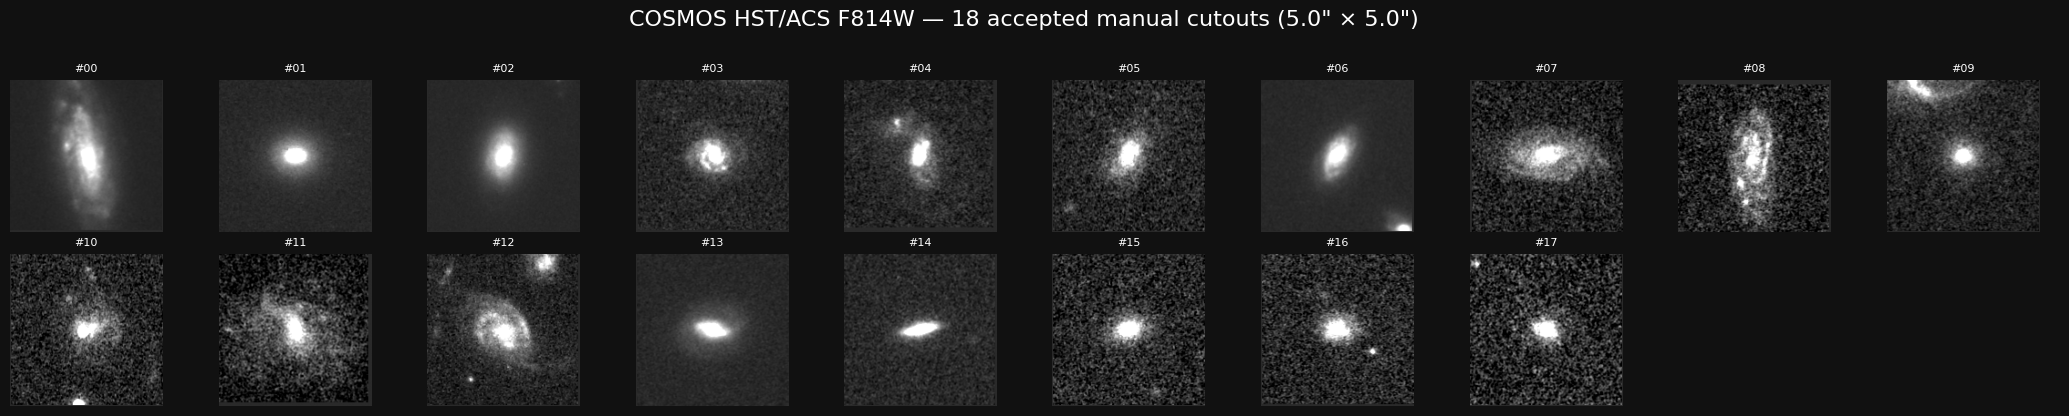

Saved grid to: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\qaplots\galaxy_grid.jpg


In [11]:
accepted_names = accepted_df['filename'].tolist()
num_accept = len(accepted_names)

if num_accept == 0:
    print('No accepted cutouts available for plotting.')
else:
    ncols = 10
    nrows = math.ceil(num_accept / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.1 * ncols, 2.1 * nrows), facecolor='#111111')

    axes = np.array(axes).reshape(nrows, ncols)
    for ax in axes.ravel():
        ax.set_facecolor('#111111')
        ax.axis('off')

    for i, name in enumerate(accepted_names):
        ax = axes.ravel()[i]
        ax.imshow(image_store[name], cmap='gray', origin='lower', vmin=-0.2, vmax=1.0)
        ax.set_title(f'#{i:02d}', color='white', fontsize=8)
        ax.axis('off')

    fig.suptitle(
        f'COSMOS HST/ACS F814W — {num_accept} accepted manual cutouts ({CUTOUT_SIZE_ARCSEC:.1f}" × {CUTOUT_SIZE_ARCSEC:.1f}")',
        color='white', fontsize=16
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    grid_path = PLOT_DIR / 'galaxy_grid.jpg'
    fig.savefig(grid_path, dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
    plt.show()
    print('Saved grid to:', grid_path.resolve())

## Cell 11 — Quick scientific sanity checks

These checks help confirm that the exported library is internally consistent.

In [12]:
if len(accepted_df) == 0:
    print('No accepted cutouts to summarise.')
else:
    summary = accepted_df[[
        'shape', 'pixel_scale_arcsec', 'cutout_size_arcsec',
        'sky_level', 'p99_flux', 'std_norm', 'peak_norm'
    ]].describe().round(4)
    display(summary)

    print('Unique shapes among accepted cutouts:')
    print(accepted_df[['shape']].drop_duplicates().sort_values(['shape']).to_string(index=False))

KeyError: "None of [Index(['shape', 'pixel_scale_arcsec', 'cutout_size_arcsec', 'sky_level',\n       'p99_flux', 'std_norm', 'peak_norm'],\n      dtype='object')] are in the [columns]"

## Cell 12 — Notes for your GSoC Stage 0 workflow

This manual-only notebook is deliberately limited to **source-library preparation**.

### What it does well
- keeps the workflow clean and reproducible,
- prevents the metadata RA/Dec bug by storing true coordinates,
- guarantees `.npy` export verification,
- adds simple image-level QA and manual rejection support.

### What it does **not** do
- no automatic IRSA querying,
- no catalog-based star rejection,
- no morphology-based catalog cuts,
- no lenstronomy injection yet.

### Recommended workflow
1. Build your target list elsewhere.
2. Download only the cutouts you actually want.
3. Put them in `RAW_DIR`.
4. Run this notebook.
5. Review `qa_plots/galaxy_grid.jpg` and `rejected_cutouts.csv`.
6. Add bad files to `REJECT_BY_FILENAME` if needed and rerun Cells 5 onward.
7. Use the resulting `.npy` files as source inputs for your next lenstronomy notebook.

Original .npy directory: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\npy
Masked .npy directory:   C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_cutouts\masked_npy
Found 18 original .npy files
Found 18 masked .npy files


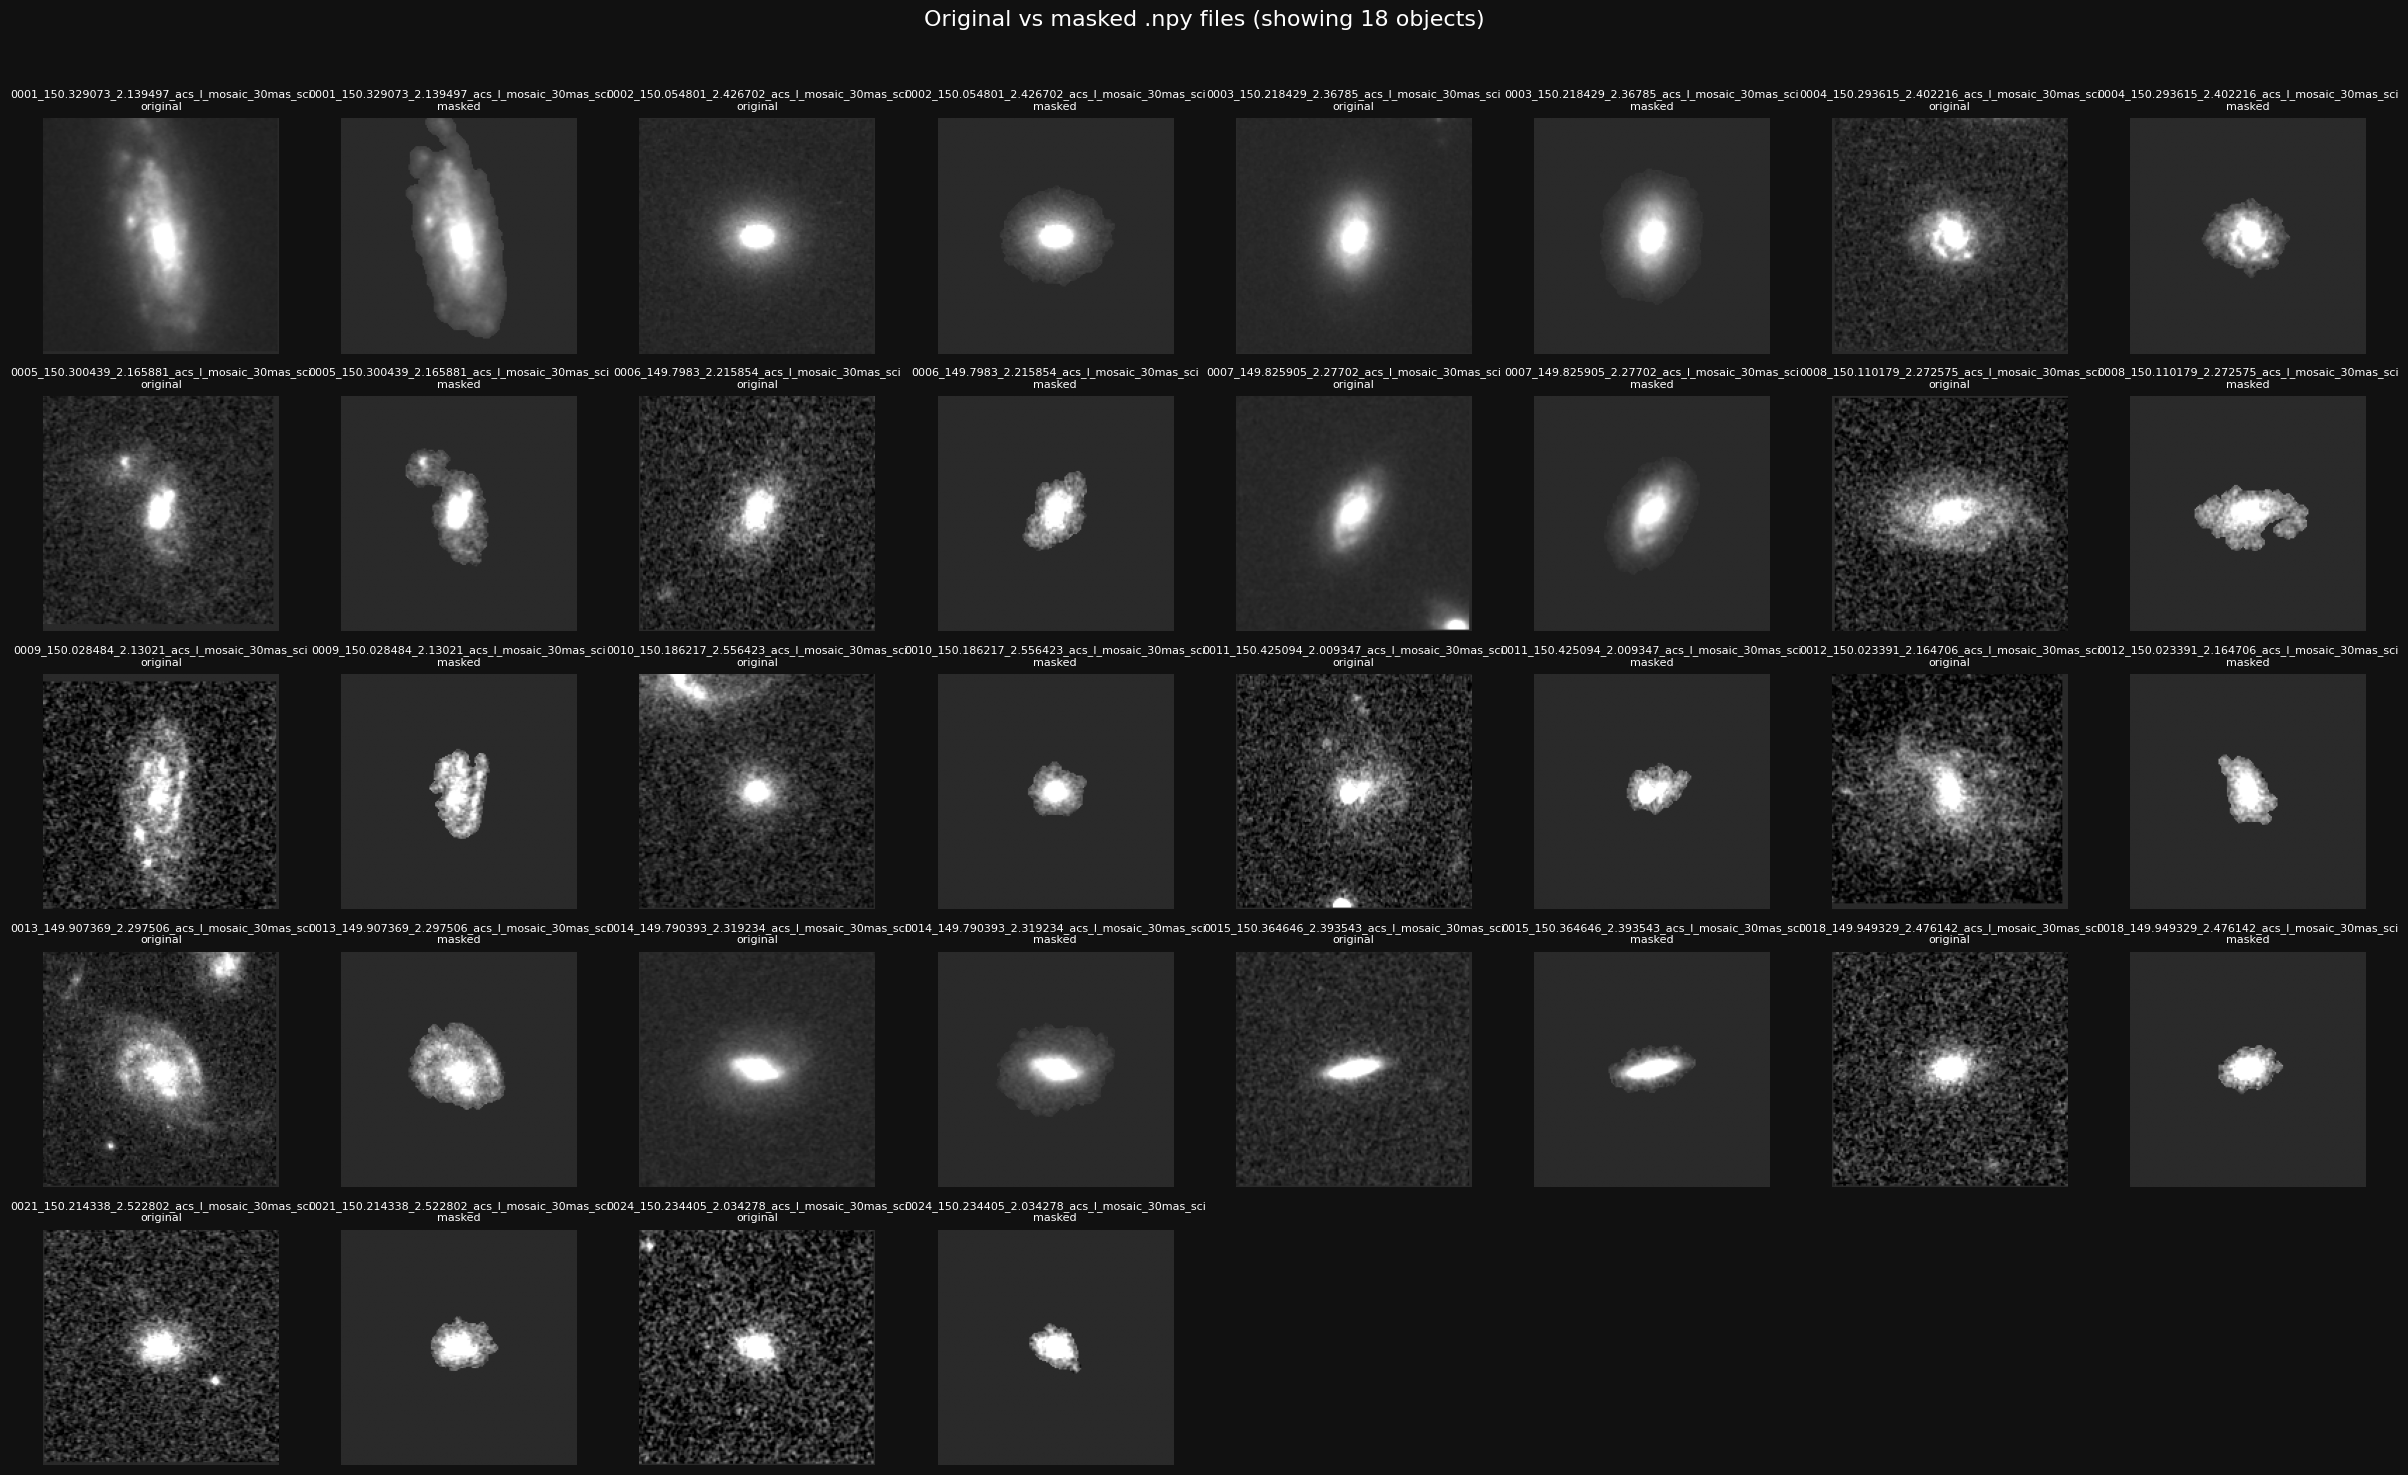

In [13]:
# Cell X — Visualize exported .npy and masked .npy files side by side

import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# How many examples to show
MAX_SHOW = 24

# Display stretch
VMIN = -0.2
VMAX = 1.0

# Directories expected from the export cells
orig_dir = NPY_DIR
masked_dir = MASKED_NPY_DIR if "MASKED_NPY_DIR" in globals() else (OUT_DIR / "masked_npy")
# masked_dir = MASK_DIR if "MASK_DIR" in globals() else (OUT_DIR / "mask")

orig_files = sorted(orig_dir.glob("*.npy"))
masked_files = sorted(masked_dir.glob("*.npy")) if masked_dir.exists() else []

print(f"Original .npy directory: {orig_dir.resolve()}")
print(f"Masked .npy directory:   {masked_dir.resolve()}")
print(f"Found {len(orig_files)} original .npy files")
print(f"Found {len(masked_files)} masked .npy files")

if len(orig_files) == 0:
    print("No original .npy files found.")
else:
    stems = [fp.stem for fp in orig_files[:MAX_SHOW]]

    ncols = 4 if len(masked_files) > 0 else 6
    nrows = math.ceil(len(stems) / ncols)

    if len(masked_files) > 0:
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=2 * ncols,
            figsize=(3.0 * 2 * ncols, 3.0 * nrows),
            facecolor="#111111"
        )
        axes = np.array(axes).reshape(nrows, 2 * ncols)

        for ax in axes.ravel():
            ax.set_facecolor("#111111")
            ax.axis("off")

        for i, stem in enumerate(stems):
            r = i // ncols
            c = i % ncols

            ax1 = axes[r, 2 * c]
            ax2 = axes[r, 2 * c + 1]

            orig_path = orig_dir / f"{stem}.npy"
            masked_path = masked_dir / f"{stem}.npy"

            orig = np.load(orig_path)
            ax1.imshow(orig, cmap="gray", origin="lower", vmin=VMIN, vmax=VMAX)
            ax1.set_title(f"{stem}\noriginal", color="white", fontsize=8)
            ax1.axis("off")

            if masked_path.exists():
                masked = np.load(masked_path)
                ax2.imshow(masked, cmap="gray", origin="lower", vmin=VMIN, vmax=VMAX)
                ax2.set_title(f"{stem}\nmasked", color="white", fontsize=8)
            else:
                ax2.text(
                    0.5, 0.5, "no masked file",
                    color="white", ha="center", va="center", fontsize=9
                )
                ax2.set_title(f"{stem}\nmasked", color="white", fontsize=8)
            ax2.axis("off")

        fig.suptitle(
            f"Original vs masked .npy files (showing {len(stems)} objects)",
            color="white",
            fontsize=16
        )
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    else:
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(2.8 * ncols, 2.8 * nrows),
            facecolor="#111111"
        )
        axes = np.array(axes).reshape(nrows, ncols)

        for ax in axes.ravel():
            ax.set_facecolor("#111111")
            ax.axis("off")

        for i, stem in enumerate(stems):
            r = i // ncols
            c = i % ncols
            ax = axes[r, c]

            arr = np.load(orig_dir / f"{stem}.npy")
            ax.imshow(arr, cmap="gray", origin="lower", vmin=VMIN, vmax=VMAX)
            ax.set_title(stem, color="white", fontsize=8)
            ax.axis("off")

        fig.suptitle(
            f"Original .npy files (showing {len(stems)} objects)",
            color="white",
            fontsize=16
        )
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

In [14]:
manifest_df[["filename", "status", "reason"]].copy()
manifest_df["reason"].str.split(";").explode().value_counts()

reason
r2_main_object_too_weak                          19
passed_auto_qa                                   18
r1_dominant_component_far_from_catalog_center    11
r1_no_component_detected                          6
r2_no_component_detected                          6
r1_dominant_component_not_centered                2
Name: count, dtype: int64